In [2]:
# Student name: Amir Gharghabi
# Course: ML
# HW5
# Q6

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler


In [27]:
dataset_path = 'dataset/fer2013.csv'

data = pd.read_csv(dataset_path)

In [4]:
data.shape

(35887, 3)

In [5]:
data.head

<bound method NDFrame.head of        emotion                                             pixels        Usage
0            0  70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...     Training
1            0  151 150 147 155 148 133 111 140 170 174 182 15...     Training
2            2  231 212 156 164 174 138 161 173 182 200 106 38...     Training
3            4  24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...     Training
4            6  4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...     Training
...        ...                                                ...          ...
35882        6  50 36 17 22 23 29 33 39 34 37 37 37 39 43 48 5...  PrivateTest
35883        3  178 174 172 173 181 188 191 194 196 199 200 20...  PrivateTest
35884        0  17 17 16 23 28 22 19 17 25 26 20 24 31 19 27 9...  PrivateTest
35885        3  30 28 28 29 31 30 42 68 79 81 77 67 67 71 63 6...  PrivateTest
35886        2  19 13 14 12 13 16 21 33 50 57 71 84 97 108 122...  PrivateTest

[35887 rows x 3 colum

In [6]:
data.describe

<bound method NDFrame.describe of        emotion                                             pixels        Usage
0            0  70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...     Training
1            0  151 150 147 155 148 133 111 140 170 174 182 15...     Training
2            2  231 212 156 164 174 138 161 173 182 200 106 38...     Training
3            4  24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...     Training
4            6  4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...     Training
...        ...                                                ...          ...
35882        6  50 36 17 22 23 29 33 39 34 37 37 37 39 43 48 5...  PrivateTest
35883        3  178 174 172 173 181 188 191 194 196 199 200 20...  PrivateTest
35884        0  17 17 16 23 28 22 19 17 25 26 20 24 31 19 27 9...  PrivateTest
35885        3  30 28 28 29 31 30 42 68 79 81 77 67 67 71 63 6...  PrivateTest
35886        2  19 13 14 12 13 16 21 33 50 57 71 84 97 108 122...  PrivateTest

[35887 rows x 3 c

In [28]:
# Split the pixel intensities by space and convert them to floats
data['pixels'] = data['pixels'].apply(lambda x: np.array(x.split(), dtype='float32'))
X = np.vstack(data['pixels'].values)
#pca = PCA()
#pca.fit(X)

In [25]:
X

array([[ 70.,  80.,  82., ..., 106., 109.,  82.],
       [151., 150., 147., ..., 193., 183., 184.],
       [231., 212., 156., ...,  88., 110., 152.],
       ...,
       [ 17.,  17.,  16., ..., 154., 133., 113.],
       [ 30.,  28.,  28., ...,  35.,  30.,  28.],
       [ 19.,  13.,  14., ..., 189., 199., 201.]], dtype=float32)

In [8]:
eigenvalues = pca.explained_variance_
eigenvalues_descending = np.sort(eigenvalues)[::-1]

# Print the eigenvalues in descending order
print(eigenvalues_descending)

[2.6651232e+06 9.0313669e+05 8.6841450e+05 ... 4.2908258e+00 4.1755352e+00
 3.8545706e+00]


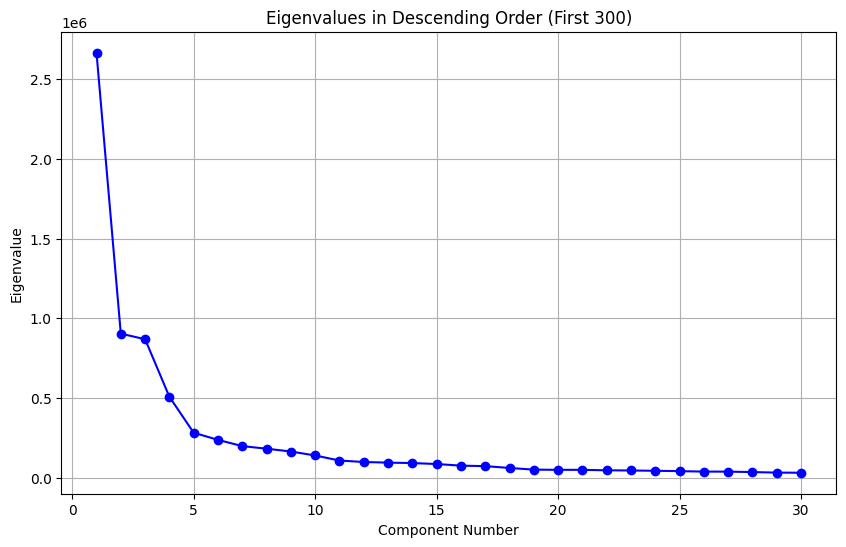

In [9]:
plt.figure(figsize=(10, 6))
number_of_eig = 30
plt.plot(range(1, number_of_eig+1), eigenvalues_descending[:number_of_eig], marker='o', linestyle='-', color='b')
plt.xlabel('Component Number')
plt.ylabel('Eigenvalue')
plt.title('Eigenvalues in Descending Order (First 300)')
plt.grid(True)
plt.show()

In [10]:
X

array([[ 70.,  80.,  82., ..., 106., 109.,  82.],
       [151., 150., 147., ..., 193., 183., 184.],
       [231., 212., 156., ...,  88., 110., 152.],
       ...,
       [ 17.,  17.,  16., ..., 154., 133., 113.],
       [ 30.,  28.,  28., ...,  35.,  30.,  28.],
       [ 19.,  13.,  14., ..., 189., 199., 201.]], dtype=float32)

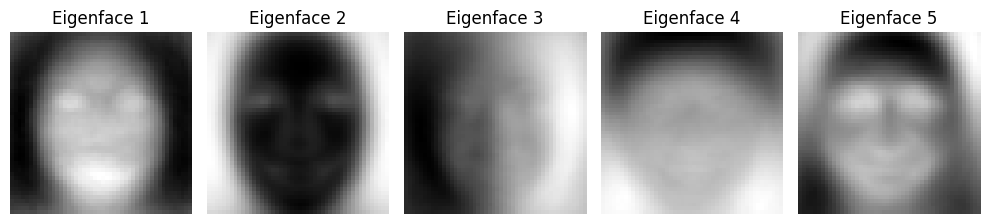

In [11]:
desired_class = 3 # Happy
filtered_data = data[data['emotion'] == desired_class]

# 2. Extract pixel values and perform PCA
X_filtered = np.vstack(filtered_data['pixels'].values)
pca = PCA()
pca.fit(X_filtered)

first_5_eigenfaces = pca.components_[:5]

# 4. Visualize the first 5 eigenfaces
plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    eigenface = first_5_eigenfaces[i].reshape(48, 48)
    plt.imshow(eigenface, cmap='gray')
    plt.title(f'Eigenface {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [33]:
dataset_path = 'dataset/fer2013.csv'
data = pd.read_csv(dataset_path)

# Preprocess the data
data['pixels'] = data['pixels'].apply(lambda x: [int(pixel) for pixel in x.split()])  # Convert string to list of integers

# Convert pixel values to a numerical format suitable for PCA
pixel_values = data['pixels'].to_list()
pixel_array = np.array(pixel_values)
X = StandardScaler().fit_transform(pixel_array)  # Standardize the pixel values

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, data['emotion'], test_size=0.2, random_state=42)

# Apply PCA
num_components = 5  # Number of principal components to keep
pca = PCA(n_components=num_components)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# KNN Classifier with scaled data
knn_scaled = KNeighborsClassifier()
knn_scaled.fit(X_train, y_train)
y_pred_scaled = knn_scaled.predict(X_test)
accuracy_scaled = accuracy_score(y_test, y_pred_scaled)
print(f"Accuracy with scaled data: {accuracy_scaled}")

# KNN Classifier with PCA-reduced data
knn_pca = KNeighborsClassifier()
knn_pca.fit(X_train_pca, y_train)
y_pred_pca = knn_pca.predict(X_test_pca)
accuracy_pca = accuracy_score(y_test, y_pred_pca)
print(f"Accuracy with PCA-reduced data: {accuracy_pca}")

Accuracy with scaled data: 0.35399832822513233
Accuracy with PCA-reduced data: 0.2751462803009195


In [41]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

Scaled Data:
Accuracy: 0.35399832822513233


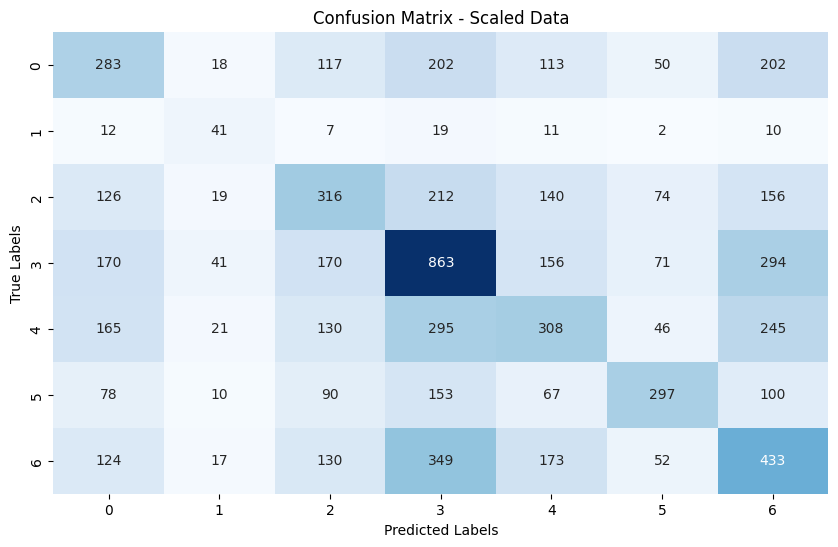

Classification Report:

PCA-Reduced Data:
Accuracy: 0.2751462803009195


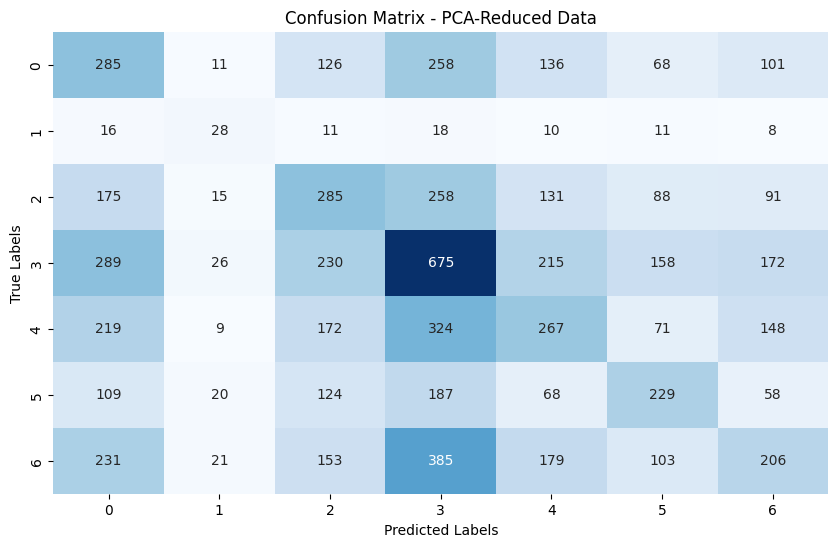

In [45]:
# Calculate accuracy and confusion matrix for scaled data
accuracy_scaled = accuracy_score(y_test, y_pred_scaled)
confusion_matrix_scaled = confusion_matrix(y_test, y_pred_scaled)
classification_report_scaled = classification_report(y_test, y_pred_scaled)

print("Scaled Data:")
print(f"Accuracy: {accuracy_scaled}")
plt.figure(figsize=(10, 6))
sns.heatmap(confusion_matrix_scaled, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Scaled Data')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

print("Classification Report:")
#print(classification_report_scaled)
print()

knn_pca = KNeighborsClassifier()
knn_pca.fit(X_train_pca, y_train)
y_pred_pca = knn_pca.predict(X_test_pca)

accuracy_pca = accuracy_score(y_test, y_pred_pca)
confusion_matrix_pca = confusion_matrix(y_test, y_pred_pca)
classification_report_pca = classification_report(y_test, y_pred_pca)

print("PCA-Reduced Data:")
print(f"Accuracy: {accuracy_pca}")
plt.figure(figsize=(10, 6))
sns.heatmap(confusion_matrix_pca, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - PCA-Reduced Data')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()